In [147]:
import cv2
import numpy as np
import joblib
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops

In [148]:
MODEL_NAME = "ann"   # "knn" atau "ann"
SIZE = 128 # 32, 64, 128, 256
PATH = "img.jpg" # yang akan diprediksi

# Load model

In [149]:
model = joblib.load(
    f"models/{MODEL_NAME}/{SIZE}/grape_{MODEL_NAME}.pkl"
)

# Load scaler
scaler = joblib.load(
    f"features/{SIZE}/grape_scaler.pkl"
)

# Load LabelEncoder hanya untuk ANN
if MODEL_NAME == "ann":
    le = joblib.load(
        f"models/ann/{SIZE}/grape_label_encoder.pkl"
    )
else:
    le = None

# Fungsi Prepro

In [150]:
def segment_leaf_hsv(image_bgr, min_area_ratio=0.01):
    """
    Segmentasi daun dengan HSV + pembersihan komponen.
    - Menggabungkan rentang warna daun (hijau/kuning/coklat/merah)
    - Menolak piksel low-saturation (background kusam)
    - Menyisakan komponen terbesar agar background tidak ikut
    """
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)

    # Rentang warna daun (lebih ketat)
    lower_green = np.array([20, 35, 25])
    upper_green = np.array([95, 255, 255])

    lower_yellow = np.array([15, 40, 35])
    upper_yellow = np.array([35, 255, 255])

    lower_brown = np.array([5, 50, 20])
    upper_brown = np.array([20, 255, 220])

    lower_red1 = np.array([0, 50, 30])
    upper_red1 = np.array([12, 255, 255])
    lower_red2 = np.array([160, 50, 30])
    upper_red2 = np.array([180, 255, 255])

    # Mask warna
    mask_color  = cv2.inRange(hsv, lower_green, upper_green)
    mask_color |= cv2.inRange(hsv, lower_yellow, upper_yellow)
    mask_color |= cv2.inRange(hsv, lower_brown, upper_brown)
    mask_color |= cv2.inRange(hsv, lower_red1, upper_red1)
    mask_color |= cv2.inRange(hsv, lower_red2, upper_red2)

    # Tolak background abu/gelap (S dan V terlalu rendah)
    mask_sv = cv2.inRange(hsv, np.array([0, 35, 25]), np.array([180, 255, 255]))
    mask = cv2.bitwise_and(mask_color, mask_sv)

    # Morphological cleaning
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    # Keep komponen terbesar (leaf utama)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    refined = np.zeros_like(mask)

    if num_labels > 1:
        areas = stats[1:, cv2.CC_STAT_AREA]  # abaikan background index 0
        largest_idx = 1 + np.argmax(areas)
        largest_area = stats[largest_idx, cv2.CC_STAT_AREA]

        h, w = mask.shape[:2]
        min_area = int(min_area_ratio * h * w)

        if largest_area >= min_area:
            refined[labels == largest_idx] = 255
        else:
            refined = mask.copy()
    else:
        refined = mask.copy()

    # Haluskan tepi akhir
    refined = cv2.medianBlur(refined, 5)
    result = cv2.bitwise_and(image_bgr, image_bgr, mask=refined)
    return result, refined

In [151]:
def apply_clahe(image_bgr, clip_limit=2.0, tile_grid=(8, 8)):
    """
    Menerapkan CLAHE pada kanal L (Lightness) di ruang warna LAB.
    Kontras diperbaiki secara lokal tanpa mengubah pigmen warna asli.
    """
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    l_eq = clahe.apply(l_channel)

    lab_eq = cv2.merge([l_eq, a_channel, b_channel])
    result = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2BGR)
    return result

In [152]:
def zero_pad_and_resize(image_bgr, target_size):
    """
    1. Zero-padding → jadikan persegi (sisi = max(h, w))
    2. Resize       → target_size × target_size
    Aspect ratio asli dipertahankan; area tambahan diisi hitam.
    """
    h, w = image_bgr.shape[:2]
    max_side = max(h, w)

    # Buat canvas hitam persegi
    canvas = np.zeros((max_side, max_side, 3), dtype=np.uint8)

    # Letakkan gambar di tengah canvas
    y_offset = (max_side - h) // 2
    x_offset = (max_side - w) // 2
    canvas[y_offset:y_offset + h, x_offset:x_offset + w] = image_bgr

    # Resize ke target
    resized = cv2.resize(canvas, (target_size, target_size),
                         interpolation=cv2.INTER_AREA)
    return resized

In [153]:
def normalize_minmax(image_bgr):
    """
    Min-Max Normalization: pixel / 255.0
    Output bertipe float32 dengan rentang [0, 1].
    """
    return image_bgr.astype(np.float32) / 255.0

# Fungsi Ekstraksi Fitur

In [154]:
def extract_hsv_hist_features(
    image_bgr,
    grid_size=(2, 2),   # 4-kuadran
    bins_h=8,
    bins_s=8,
    bins_v=8
):
    """
    Ekstraksi fitur warna HSV histogram per kuadran.
    Output: vektor fitur 1D.
    """
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    h, w = hsv.shape[:2]
    gh, gw = grid_size

    features = []

    for i in range(gh):
        for j in range(gw):
            y0 = int(i * h / gh)
            y1 = int((i + 1) * h / gh)
            x0 = int(j * w / gw)
            x1 = int((j + 1) * w / gw)

            cell = hsv[y0:y1, x0:x1]

            hist_h = cv2.calcHist([cell], [0], None, [bins_h], [0, 180])
            hist_s = cv2.calcHist([cell], [1], None, [bins_s], [0, 256])
            hist_v = cv2.calcHist([cell], [2], None, [bins_v], [0, 256])

            hist_h = cv2.normalize(hist_h, None).flatten()
            hist_s = cv2.normalize(hist_s, None).flatten()
            hist_v = cv2.normalize(hist_v, None).flatten()

            features.extend(hist_h)
            features.extend(hist_s)
            features.extend(hist_v)

    return np.array(features, dtype=np.float32)

In [155]:
def extract_glcm_features(
    image_bgr,
    distances=(1, 2, 3),
    angles=(0, np.pi / 4, np.pi / 2, 3 * np.pi / 4),
    levels=32
):
    """
    Ekstraksi fitur tekstur menggunakan GLCM pada grayscale.
    Output: vektor fitur 1D.
    """
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

    # Kuantisasi grayscale ke levels tertentu
    gray_q = np.floor(gray.astype(np.float32) * levels / 256.0).astype(np.uint8)
    gray_q = np.clip(gray_q, 0, levels - 1)

    glcm = graycomatrix(
        gray_q,
        distances=list(distances),
        angles=list(angles),
        levels=levels,
        symmetric=True,
        normed=True
    )

    props = ["contrast", "homogeneity", "energy", "correlation"]
    features = []

    for prop in props:
        values = graycoprops(glcm, prop)
        features.extend(values.flatten())

    return np.array(features, dtype=np.float32)

In [156]:
def preprocess_for_features(image_bgr):
    """
    Menggunakan preprocessing yang sudah ada:
    1. HSV masking
    2. CLAHE
    3. Zero-padding + resize
    4. Normalisasi
    Lalu dikembalikan ke uint8 agar aman untuk histogram dan GLCM.
    """
    seg, _ = segment_leaf_hsv(image_bgr)
    clahe = apply_clahe(seg)
    resized = zero_pad_and_resize(clahe, SIZE)
    normalized = normalize_minmax(resized)

    # Balik ke uint8 supaya cocok untuk ekstraksi fitur
    processed = (normalized * 255).astype(np.uint8)
    return processed

In [157]:
def extract_combined_features(image_bgr):
    hsv_features = extract_hsv_hist_features(image_bgr)
    glcm_features = extract_glcm_features(image_bgr)
    return np.concatenate([hsv_features, glcm_features]).astype(np.float32)

# Fungsi Prediksi 

In [158]:
def predict_grape_leaf(image_path, show_image=True):

    # ==================================================
    # Baca gambar
    # ==================================================
    image = cv2.imread(image_path)

    if image is None:
        print("Gagal membaca gambar!")
        return

    # ==================================================
    # Preprocessing
    # ==================================================
    processed = preprocess_for_features(image)

    # ==================================================
    # Ekstraksi fitur
    # ==================================================
    features = extract_combined_features(processed)

    # Ubah menjadi 2D
    features = features.reshape(1, -1)

    # ==================================================
    # Scaling
    # ==================================================
    features_scaled = scaler.transform(features)

    # ==================================================
    # Prediksi
    # ==================================================
    prediction = model.predict(features_scaled)

    probabilities = model.predict_proba(features_scaled)[0]

    # ==================================================
    # Tentukan label
    # ==================================================
    if le is None:

        # KNN
        predicted_label = prediction[0]

        class_names = model.classes_

    else:

        # ANN
        predicted_label = le.inverse_transform(prediction)[0]

        class_names = le.classes_

    # ==================================================
    # Confidence tertinggi
    # ==================================================
    best_idx = np.argmax(probabilities)
    best_confidence = probabilities[best_idx] * 100

    # ==================================================
    # Tampilkan gambar
    # ==================================================
    if show_image:

        fig, axes = plt.subplots(1, 2, figsize=(12, 6))

        # ------------------------
        # Original Image
        # ------------------------
        axes[0].imshow(
            cv2.cvtColor(
                image,
                cv2.COLOR_BGR2RGB
            )
        )

        axes[0].set_title("Original Image")
        axes[0].axis("off")

        # ------------------------
        # Preprocessed Image
        # ------------------------
        if len(processed.shape) == 2:

            axes[1].imshow(
                processed,
                cmap="gray"
            )

        else:

            axes[1].imshow(
                cv2.cvtColor(
                    processed,
                    cv2.COLOR_BGR2RGB
                )
            )

        axes[1].set_title("After Preprocessing")
        axes[1].axis("off")

        plt.suptitle(
            f"Prediction: {predicted_label}\nConfidence: {best_confidence:.2f}%"
        )

        plt.tight_layout()
        plt.show()

    # ==================================================
    # Hasil
    # ==================================================
    print("=" * 70)
    print("HASIL PREDIKSI")
    print("=" * 70)

    print("Model      :", MODEL_NAME.upper())
    print("Prediksi   :", predicted_label)
    print("Confidence :", f"{best_confidence:.2f}%")

    print("\nConfidence Score Tiap Kelas:")

    for cls, prob in zip(class_names, probabilities):

        print(
            f"{cls:45s} : {prob*100:.2f}%"
        )

    print("=" * 70)

    return predicted_label

# Prediksi

c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


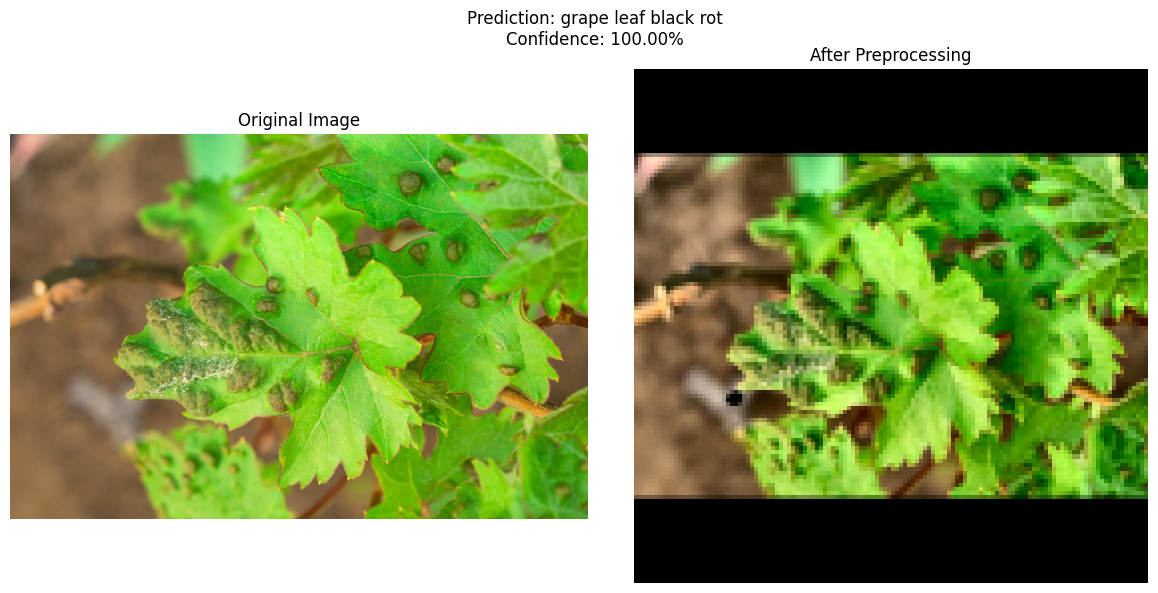

HASIL PREDIKSI
Model      : ANN
Prediksi   : grape leaf black rot
Confidence : 100.00%

Confidence Score Tiap Kelas:
Grape Esca (Black_Measles)                    : 0.00%
Grape Leaf blight (Isariopsis_Leaf_Spot)      : 0.00%
grape leaf Healthy                            : 0.00%
grape leaf black rot                          : 100.00%


'grape leaf black rot'

In [159]:
predict_grape_leaf(PATH)